# Customer Intent Intelligence
## Notebook 04 — Error Analysis

### Objective

Analyze the predictions produced by the lexical and semantic models.


## 1.Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

## 2. Load predictions

In [2]:
baseline_predictions = pd.read_csv(
    "../reports/results/baseline_predictions.csv"
)

semantic_predictions = pd.read_csv(
    "../reports/results/semantic_predictions.csv"
)

test_df = pd.read_csv(
    "../data/processed/test.csv"
)

## 3.Create analysis dataframe 

In [3]:
analysis_df = test_df[["text", "category"]].copy()

analysis_df["tfidf_lr"] = baseline_predictions["lr_prediction"]
analysis_df["tfidf_svm"] = baseline_predictions["svm_prediction"]

analysis_df["semantic_lr"] = semantic_predictions["lr_prediction"]
analysis_df["semantic_svm"] = semantic_predictions["svm_prediction"]
analysis_df["mlp"] = semantic_predictions["mlp_prediction"]

In [4]:
models = [
    "tfidf_lr",
    "tfidf_svm",
    "semantic_lr",
    "semantic_svm",
    "mlp"
]

for model in models:
    analysis_df[f"{model}_correct"] = (
        analysis_df["category"] == analysis_df[model]
    )

## 4. Model error comparison

In [5]:
error_summary = pd.DataFrame({
    "Model": models,
    "Errors": [
        (~analysis_df[f"{model}_correct"]).sum()
        for model in models
    ]
})

error_summary


,Model,Errors
0,tfidf_lr,335
1,tfidf_svm,337
2,semantic_lr,283
3,semantic_svm,223
4,mlp,287


In [6]:
error_summary["Accuracy"] = 1 - (
    error_summary["Errors"] / len(analysis_df)
)

error_summary

,Model,Errors,Accuracy
0,tfidf_lr,335,0.891234
1,tfidf_svm,337,0.890584
2,semantic_lr,283,0.908117
3,semantic_svm,223,0.927597
4,mlp,287,0.906818


## 5. best model confusion matrix

In [7]:
results = pd.read_csv(
    "../reports/results/all_model_results.csv"
)

best_model = results.loc[
    results["Validation Macro F1"].idxmax(),
    "Model"
]

print("Best model (selected on validation):", best_model)

Best model (selected on validation): Embeddings + Linear SVM


In [8]:
model_columns = {
    "TF-IDF + Logistic Regression": "tfidf_lr",
    "TF-IDF + Linear SVM": "tfidf_svm",
    "Embeddings + Logistic Regression": "semantic_lr",
    "Embeddings + Linear SVM": "semantic_svm",
    "Embeddings + MLP": "mlp"
}

best_column = model_columns[best_model]

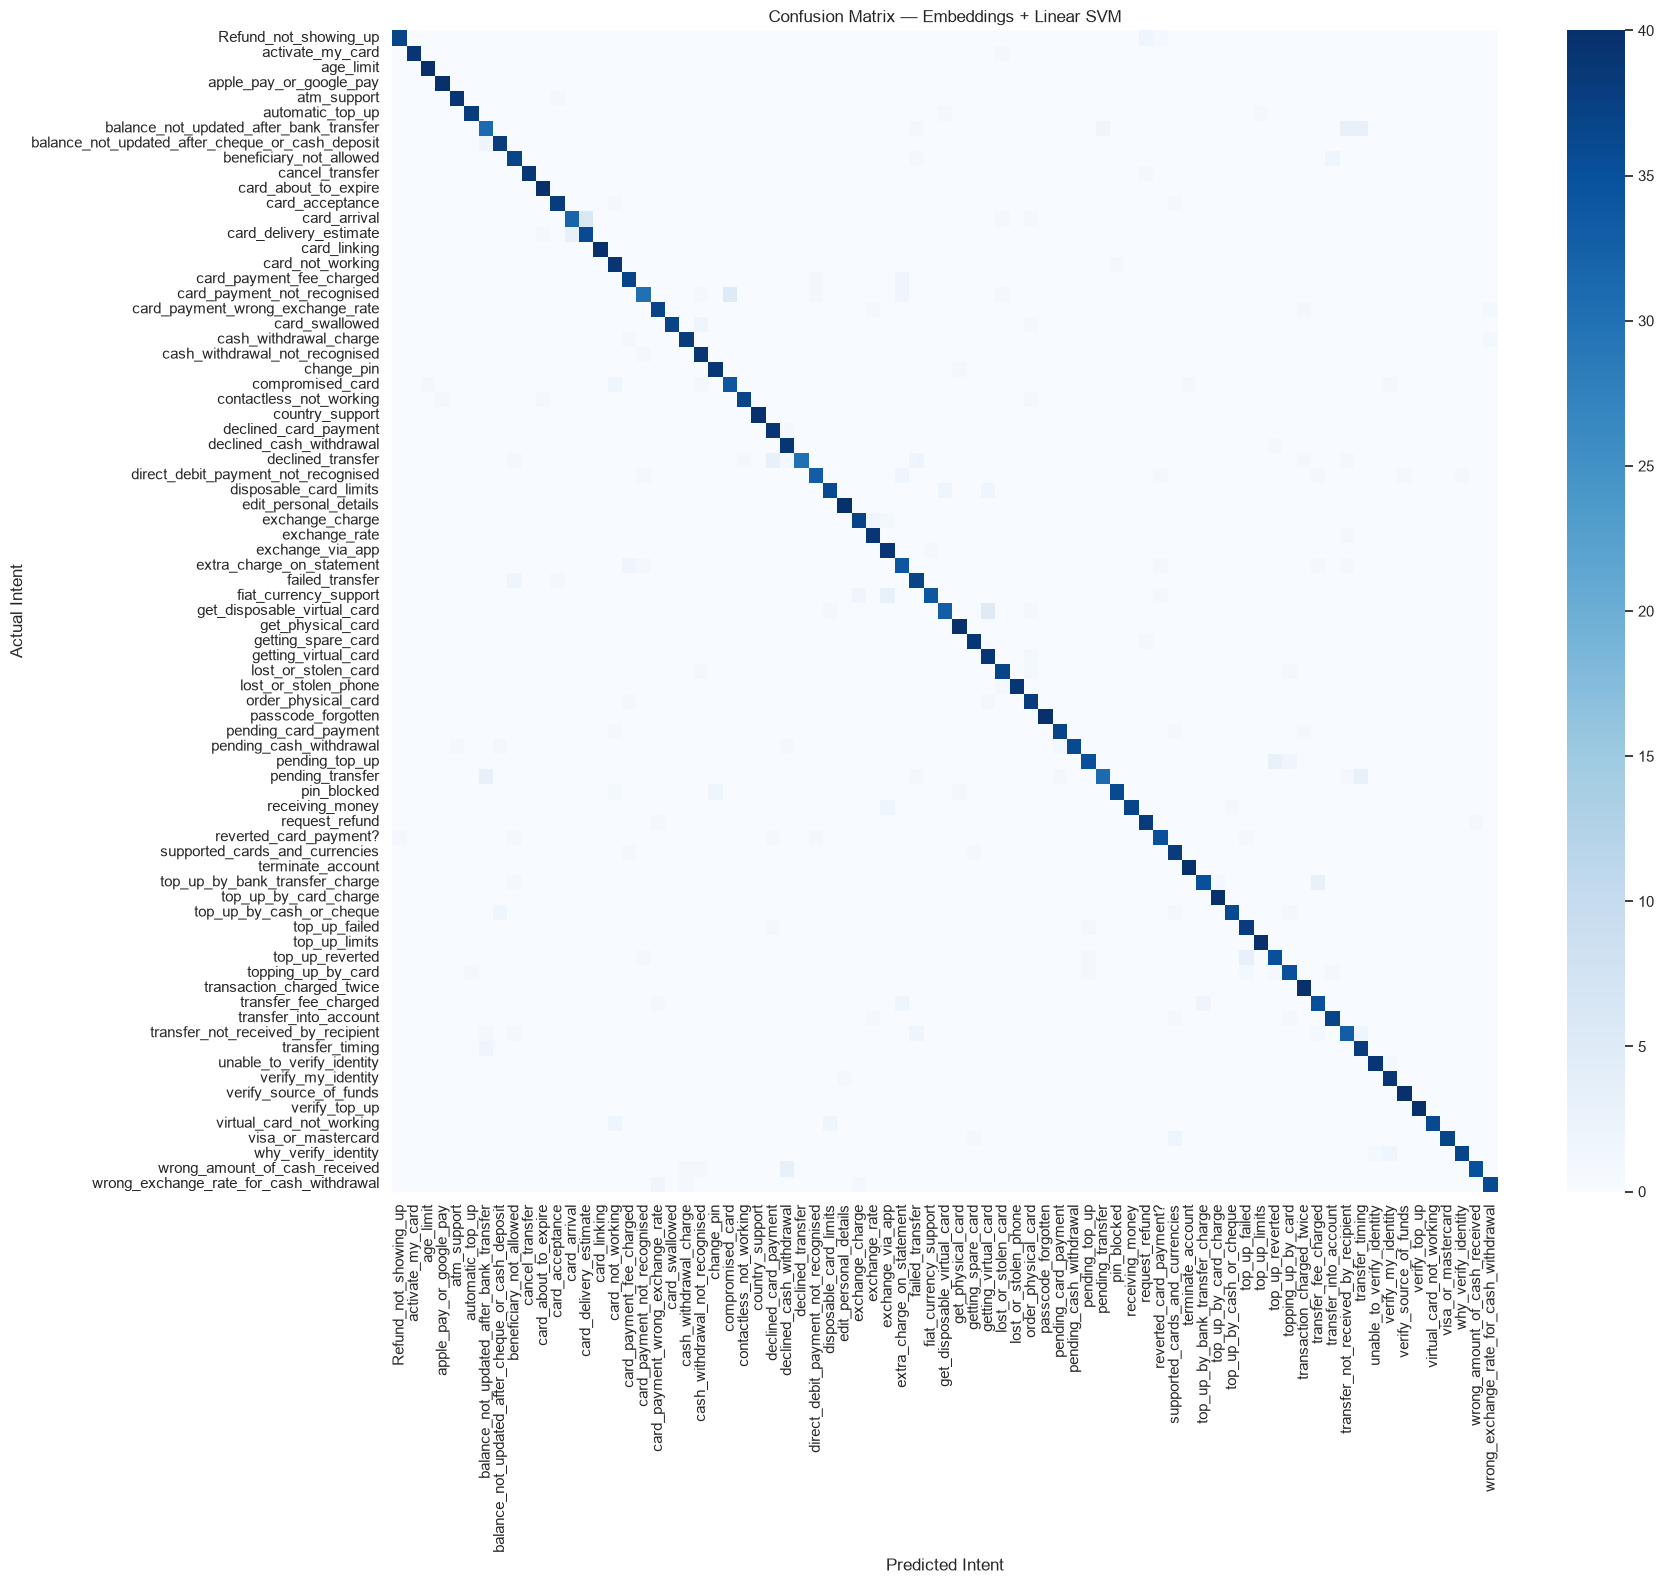

In [9]:
labels = sorted(
    analysis_df["category"].unique()
)

cm = confusion_matrix(
    analysis_df["category"],
    analysis_df[best_column],
    labels=labels
)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(f"Confusion Matrix — {best_model}")
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
confusion_pairs = []

for i, actual in enumerate(labels):
    for j, predicted in enumerate(labels):

        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "Actual": actual,
                "Predicted": predicted,
                "Count": cm[i, j]
            })

confusion_pairs_df = pd.DataFrame(
    confusion_pairs
).sort_values(
    "Count",
    ascending=False
)

confusion_pairs_df.head(15)

,Actual,Predicted,Count
16,card_arrival,card_delivery_estimate,6
25,card_payment_not_recognised,compromised_card,5
78,get_disposable_virtual_card,getting_virtual_card,5
101,pending_transfer,transfer_timing,3
9,balance_not_updated_after_bank_transfer,transfer_timing,3
75,fiat_currency_support,exchange_via_app,3
20,card_delivery_estimate,card_arrival,3
97,pending_transfer,balance_not_updated_after_bank_transfer,3
50,declined_transfer,declined_card_payment,3
126,top_up_reverted,top_up_failed,3


## Intent-level error rates

In [11]:
intent_errors = (
    analysis_df
    .groupby("category")[f"{best_column}_correct"]
    .agg(
        total="count",
        correct="sum"
    )
)

intent_errors["errors"] = (
    intent_errors["total"]
    - intent_errors["correct"]
)

intent_errors["error_rate"] = (
    intent_errors["errors"]
    / intent_errors["total"]
)

intent_errors.sort_values(
    "error_rate",
    ascending=False
).head(15)

,total,correct,errors,error_rate
category,,,,
declined_transfer,40,30,10,0.250
card_payment_not_recognised,40,30,10,0.250
balance_not_updated_after_bank_transfer,40,31,9,0.225
pending_transfer,40,31,9,0.225
card_arrival,40,32,8,0.200
direct_debit_payment_not_recognised,40,33,7,0.175
get_disposable_virtual_card,40,33,7,0.175
transfer_not_received_by_recipient,40,33,7,0.175
compromised_card,40,34,6,0.150


## Inspect actual errors

In [12]:
errors = analysis_df[
    ~analysis_df[f"{best_column}_correct"]
].copy()

errors[
    [
        "text",
        "category",
        best_column
    ]
].head(20)

,text,category,semantic_svm
0,How do I locate my card?,card_arrival,lost_or_stolen_card
2,I ordered a card but it has not arrived. Help please!,card_arrival,order_physical_card
3,Is there a way to know when my card will arrive?,card_arrival,card_delivery_estimate
5,When will I get my card?,card_arrival,card_delivery_estimate
11,How long does a card delivery take?,card_arrival,card_delivery_estimate
15,"I have been waiting longer than expected for my bank card, could you provide information on when it will arrive?",card_arrival,card_delivery_estimate
22,How long should my new card take to arrive?,card_arrival,card_delivery_estimate
32,How do I know when my card will arrive?,card_arrival,card_delivery_estimate
93,Is it a good time to exchange?,exchange_rate,transfer_not_received_by_recipient
121,I made a currency exchange and think I was charged more than I should of been.,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal


## Compare TF-IDF vs semantic model

In [13]:
tfidf_results = results[
    results["Model"].str.contains("TF-IDF")
]

semantic_results = results[
    results["Model"].str.contains("Embeddings")
]

best_tfidf = tfidf_results.loc[
    tfidf_results["Validation Macro F1"].idxmax(),
    "Model"
]

best_semantic = semantic_results.loc[
    semantic_results["Validation Macro F1"].idxmax(),
    "Model"
]

print("Best TF-IDF:", best_tfidf)
print("Best Semantic:", best_semantic)

Best TF-IDF: TF-IDF + Linear SVM
Best Semantic: Embeddings + Linear SVM


In [14]:
tfidf_column = model_columns[best_tfidf]
semantic_column = model_columns[best_semantic]

## Where semantic model helps

In [15]:
semantic_better = analysis_df[
    (~analysis_df[f"{tfidf_column}_correct"])
    &
    (analysis_df[f"{semantic_column}_correct"])
]

print(len(semantic_better))

semantic_better[
    [
        "text",
        "category",
        tfidf_column,
        semantic_column
    ]
].head(5)

183


,text,category,tfidf_svm,semantic_svm
4,My card has not arrived yet.,card_arrival,transfer_not_received_by_recipient,card_arrival
36,"I'm starting to think my card is lost because it still hasn't arrived, can you help?",card_arrival,lost_or_stolen_card,card_arrival
79,Can I link another card to my account?,card_linking,getting_spare_card,card_linking
106,The exchange rate would be?,exchange_rate,wrong_exchange_rate_for_cash_withdrawal,exchange_rate
123,The exchange rate was wrong when I bought something outside the country.,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal,card_payment_wrong_exchange_rate


##  Where TF-IDF helps

In [16]:
tfidf_better = analysis_df[
    (analysis_df[f"{tfidf_column}_correct"])
    &
    (~analysis_df[f"{semantic_column}_correct"])
]

print(len(tfidf_better))

tfidf_better[
    [
        "text",
        "category",
        tfidf_column,
        semantic_column
    ]
].head(5)

69


,text,category,tfidf_svm,semantic_svm
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,card_delivery_estimate
15,"I have been waiting longer than expected for my bank card, could you provide information on when it will arrive?",card_arrival,card_arrival,card_delivery_estimate
22,How long should my new card take to arrive?,card_arrival,card_arrival,card_delivery_estimate
32,How do I know when my card will arrive?,card_arrival,card_arrival,card_delivery_estimate
121,I made a currency exchange and think I was charged more than I should of been.,card_payment_wrong_exchange_rate,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal


## Query length analysis

In [17]:
analysis_df["word_count"] = (
    analysis_df["text"]
    .str.split()
    .str.len()
)

In [18]:
analysis_df["length_group"] = pd.cut(
    analysis_df["word_count"],
    bins=[0, 5, 10, 20, 50, np.inf],
    labels=[
        "1-5",
        "6-10",
        "11-20",
        "21-50",
        "51+"
    ]
)

Calculate error rate:

In [19]:
length_analysis = (
    analysis_df
    .groupby(
        "length_group",
        observed=True
    )[f"{best_column}_correct"]
    .mean()
    .reset_index()
)

length_analysis["error_rate"] = (
    1 - length_analysis[f"{best_column}_correct"]
)

length_analysis

,length_group,semantic_svm_correct,error_rate
0,1-5,0.928058,0.071942
1,6-10,0.925746,0.074254
2,11-20,0.930997,0.069003
3,21-50,0.928870,0.071130
4,51+,0.857143,0.142857


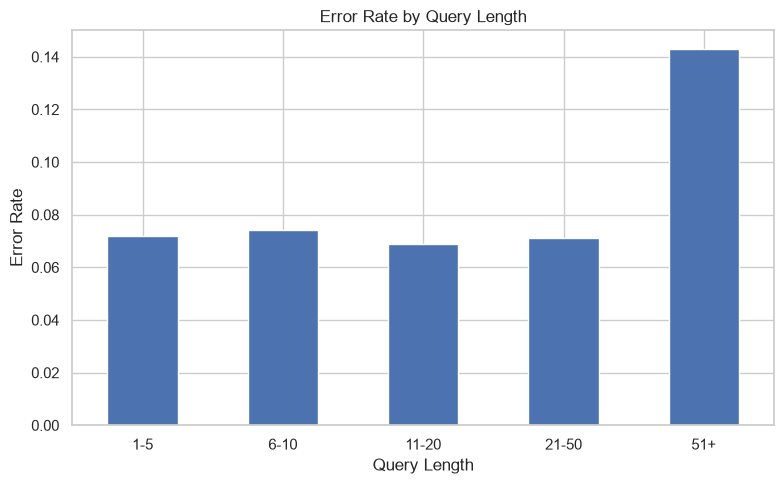

In [20]:
length_analysis.plot(
    x="length_group",
    y="error_rate",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Error Rate by Query Length")
plt.xlabel("Query Length")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Save results

In [21]:
import os

os.makedirs(
    "../reports/error_analysis",
    exist_ok=True
)

In [22]:
confusion_pairs_df.to_csv(
    "../reports/error_analysis/confusion_pairs.csv",
    index=False
)

intent_errors.to_csv(
    "../reports/error_analysis/intent_error_rates.csv"
)

errors.to_csv(
    "../reports/error_analysis/model_errors.csv",
    index=False
)

length_analysis.to_csv(
    "../reports/error_analysis/length_analysis.csv",
    index=False
)